# Линейная регрессия и регуляризация

Построим воспроизводимый baseline для прогноза числового показателя. Проведём первичный анализ данных, обучим Ridge Regression, оценим качество и разберём остатки и коэффициенты модели.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_diabetes
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

## Данные

In [2]:
dataset = load_diabetes(as_frame=True)
data = dataset.frame.rename(columns={"target": "disease_progression"})

display(data.head())
display(data.describe().T)
print("Размер:", data.shape)
print("Пропуски:", int(data.isna().sum().sum()))

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,disease_progression
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


,count,mean,std,min,25%,50%,75%,max
age,442.0,-2.511817e-19,0.047619,-0.107226,-0.037299,0.005383,0.038076,0.110727
sex,442.0,1.230790e-17,0.047619,-0.044642,-0.044642,-0.044642,0.050680,0.050680
bmi,442.0,-2.245564e-16,0.047619,-0.090275,-0.034229,-0.007284,0.031248,0.170555
bp,442.0,-4.797570e-17,0.047619,-0.112399,-0.036656,-0.005670,0.035644,0.132044
s1,442.0,-1.381499e-17,0.047619,-0.126781,-0.034248,-0.004321,0.028358,0.153914
s2,442.0,3.918434e-17,0.047619,-0.115613,-0.030358,-0.003819,0.029844,0.198788
s3,442.0,-5.777179e-18,0.047619,-0.102307,-0.035117,-0.006584,0.029312,0.181179
s4,442.0,-9.042540e-18,0.047619,-0.076395,-0.039493,-0.002592,0.034309,0.185234
s5,442.0,9.293722e-17,0.047619,-0.126097,-0.033246,-0.001947,0.032432,0.133597
s6,442.0,1.130318e-17,0.047619,-0.137767,-0.033179,-0.001078,0.027917,0.135612


Размер: (442, 11)
Пропуски: 0


## Распределение целевой переменной и корреляции

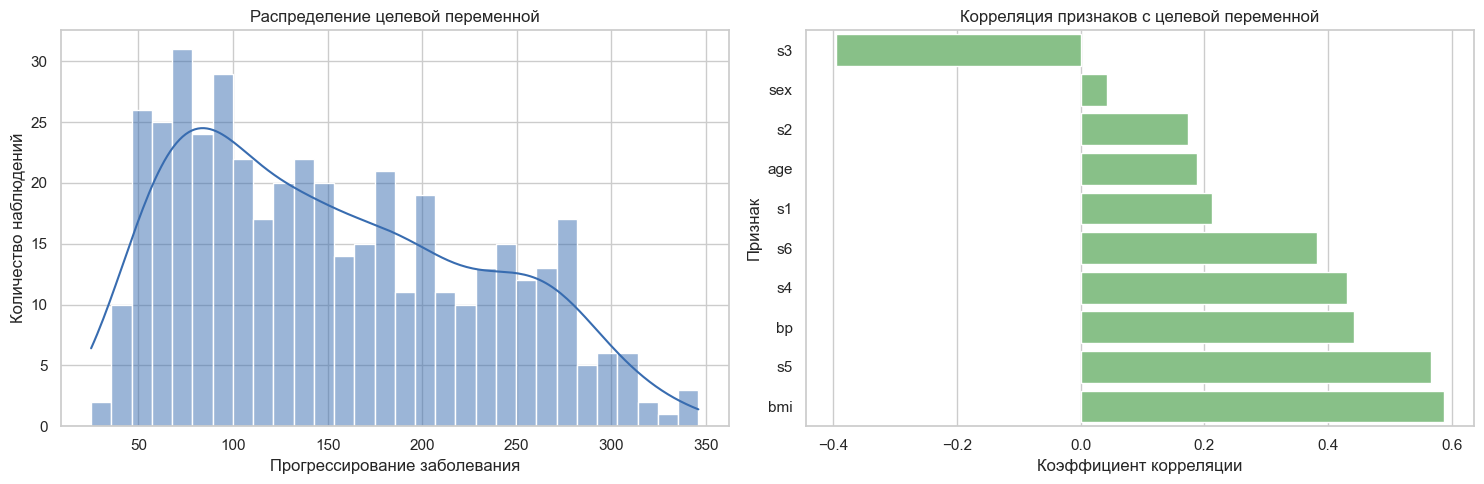

In [3]:
correlations = data.corr(numeric_only=True)["disease_progression"].drop("disease_progression").sort_values()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(data["disease_progression"], bins=30, kde=True, ax=axes[0], color="#386cb0")
axes[0].set_title("Распределение целевой переменной")
axes[0].set_xlabel("Прогрессирование заболевания")
axes[0].set_ylabel("Количество наблюдений")

sns.barplot(x=correlations.values, y=correlations.index, ax=axes[1], color="#7fc97f")
axes[1].set_title("Корреляция признаков с целевой переменной")
axes[1].set_xlabel("Коэффициент корреляции")
axes[1].set_ylabel("Признак")
plt.tight_layout()
plt.show()

## Обучение модели

In [4]:
features = data.drop(columns="disease_progression")
target = data["disease_progression"]
train_features, test_features, train_target, test_target = train_test_split(
    features, target, test_size=0.2, random_state=42
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", RidgeCV(alphas=np.logspace(-3, 3, 31))),
])
pipeline.fit(train_features, train_target)
prediction = pipeline.predict(test_features)

## Метрики

In [5]:
metrics = pd.DataFrame({
    "metric": ["MAE", "RMSE", "R2", "selected alpha"],
    "value": [
        mean_absolute_error(test_target, prediction),
        np.sqrt(mean_squared_error(test_target, prediction)),
        r2_score(test_target, prediction),
        pipeline.named_steps["model"].alpha_,
    ],
})
metrics

,metric,value
0,MAE,42.811999
1,RMSE,53.777454
2,R2,0.454147
3,selected alpha,1.000000


## Предсказания и остатки

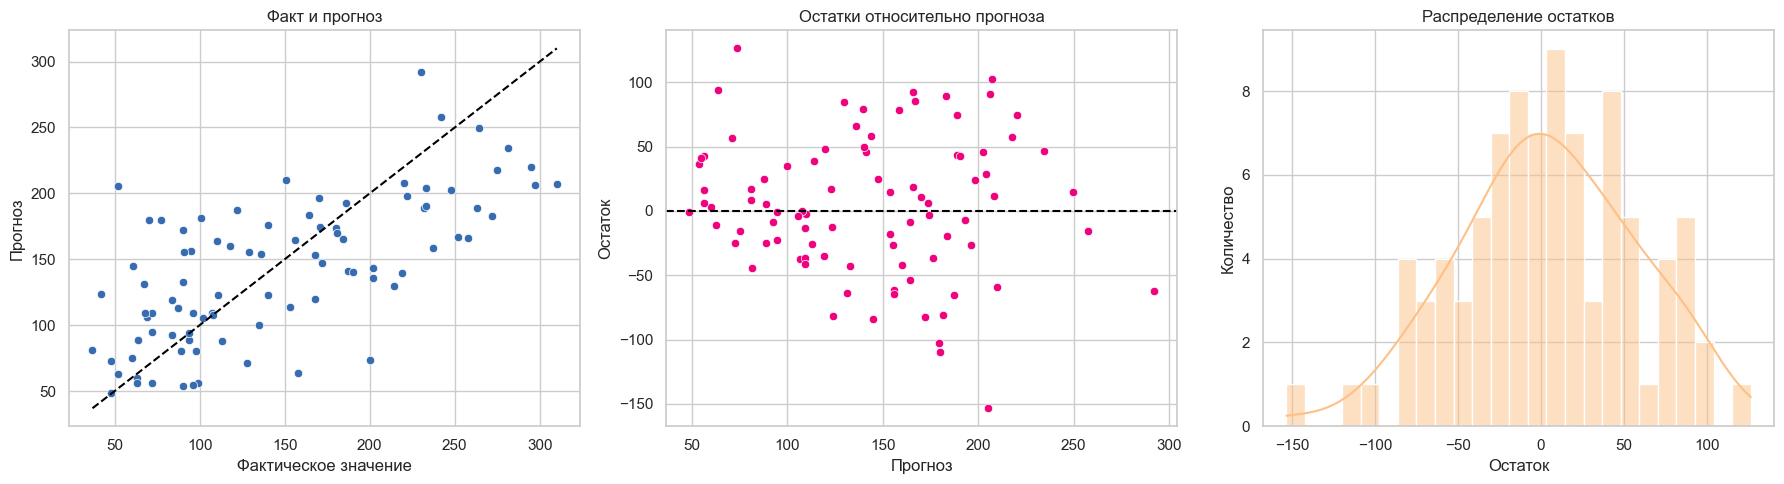

In [6]:
residuals = test_target - prediction
limits = [min(test_target.min(), prediction.min()), max(test_target.max(), prediction.max())]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(x=test_target, y=prediction, ax=axes[0], color="#386cb0")
axes[0].plot(limits, limits, linestyle="--", color="black")
axes[0].set_title("Факт и прогноз")
axes[0].set_xlabel("Фактическое значение")
axes[0].set_ylabel("Прогноз")

sns.scatterplot(x=prediction, y=residuals, ax=axes[1], color="#f0027f")
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_title("Остатки относительно прогноза")
axes[1].set_xlabel("Прогноз")
axes[1].set_ylabel("Остаток")

sns.histplot(residuals, bins=25, kde=True, ax=axes[2], color="#fdc086")
axes[2].set_title("Распределение остатков")
axes[2].set_xlabel("Остаток")
axes[2].set_ylabel("Количество")
plt.tight_layout()
plt.show()

## Коэффициенты модели

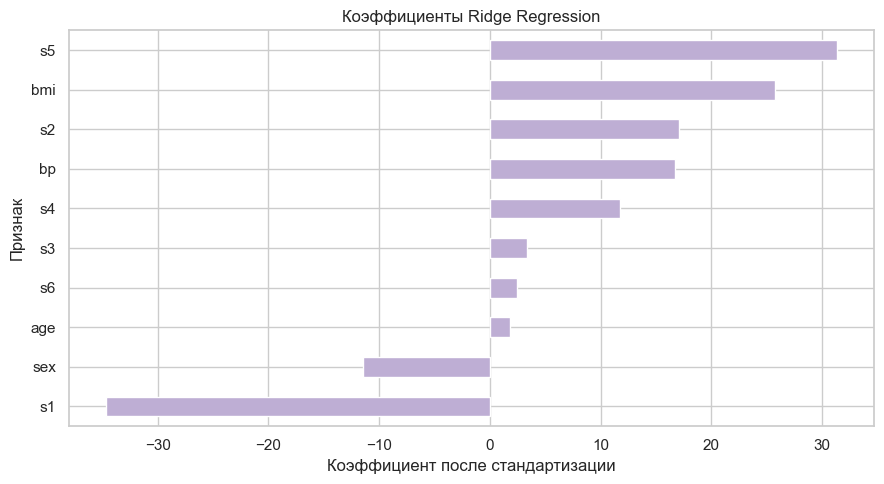

In [7]:
coefficients = pd.Series(
    pipeline.named_steps["model"].coef_,
    index=features.columns,
).sort_values()

coefficients.plot.barh(figsize=(9, 5), color="#beaed4")
plt.title("Коэффициенты Ridge Regression")
plt.xlabel("Коэффициент после стандартизации")
plt.ylabel("Признак")
plt.tight_layout()
plt.show()

## Вывод

Регуляризация ограничивает величину коэффициентов и делает линейную модель устойчивее. График «факт — прогноз» показывает общую точность, а анализ остатков помогает заметить систематические ошибки и выбросы.